The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
test torque: 5.33 N.m, test flowrate: 0.001200 m3/s
water  29800 rpm
IPA    32105 rpm


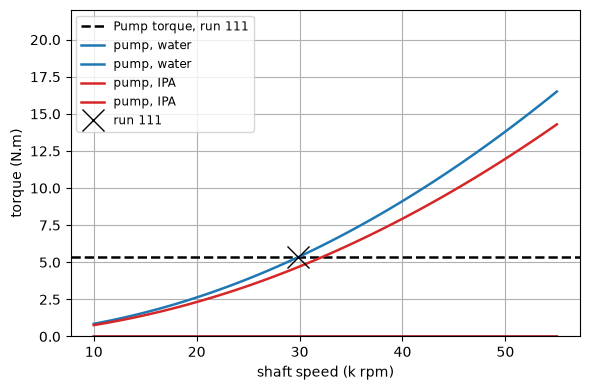

In [112]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

TESTBED = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TESTBED))

import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq
from pyfluids import FluidsList, Input
from otp.propellants.propellant import Propellant
from otp.pump.analysis import Pump
from otp.pump.records import PumpChoices, PumpGeometry, PumpRequirements
from otp.turbine.analysis import Turbine
from otp.turbine.records import TurbineChoices, TurbineGeometry, TurbineInletGas, TurbineRequirements
from otp.core.units import BAR, K_TO_C

T_K, P_IN, P_AMB = 293.15, 17.52 * BAR, 1.01325 * BAR  #K, bar, bar
N_MEAS = 29800
RPM = np.linspace(10e3, 55e3, 120)
Q_HI = 2.4e-3            # bracket top; keep below the Lock cavitation cutoff

GEOM = PumpGeometry(d_inlet=0.0298 / 1.2,
                    d_1=0.0298, 
                    d_2=0.0689,
                    b_1=0.0074,
                    b_2=0.0032,
                    d_throat=0.0062, 
                    d_outlet=0.0115,
                    d_3=0.0, 
                    b_3=0.0, 
                    s_ax=0.0)            # unused
PUMP = Pump(PumpRequirements(None, 1.2e-3, 760.0), PumpChoices(24e3, 6, 1.0), GEOM)
WATER = Propellant("Water", FluidsList.Water, t_tank=T_K, p_tank=P_IN)
ETHANOL = Propellant("Ethanol", FluidsList.Ethanol, t_tank=T_K, p_tank=P_IN)

class IPA:                      # CoolProp has no propan-2-ol; 20 C literature values
    class _s: density, kinematic_viscosity, pressure = 785.4, 2.66e-6, 4400.0
    class fluid:
        with_state = staticmethod(lambda *a: IPA._s)   # .pressure only read for p_sat

FLUIDS = {"water": (WATER, "tab:blue"), "IPA": (IPA, "tab:red")}
# FLUIDS = {"water": (WATER, "tab:blue"), "ethanol": (ETHANOL, "tab:red")}
def rho(fl):
    return fl.fluid.with_state(Input.pressure(1 * BAR), Input.temperature(T_K + K_TO_C)).density

CD = 0.71
D_OR = 0.004

def pump_torque(n, fl):
    """Torque on the 4 mm orifice line: Q where pump dp drives that flow."""
    A = np.pi / 4 * D_OR ** 2
    A, r = np.pi / 4 * D_OR ** 2, rho(fl)
    f = lambda Q: CD * A * np.sqrt(2 * max(PUMP.point_performance(fl, Q, n, P_IN, T_K, "lock").p_outlet - P_AMB, 0) / rho(fl)) - Q
    solved_Q = brentq(f, 1e-7, Q_HI)
    return PUMP.point_performance(fl, solved_Q, n, P_IN, T_K, "lock").torque, solved_Q

test_torque, test_solved_Q = pump_torque(N_MEAS, WATER)
print(f"test torque: {test_torque:.2f} N.m, test flowrate: {test_solved_Q:.6f} m3/s")

# horizontal line turbine torque
fig = plt.figure(figsize=(6, 4))
plt.axhline(test_torque, color="k", lw=1.8, ls="--", label="Pump torque, run 111")
for name, (fl, c) in FLUIDS.items():
    tq = np.array([pump_torque(n, fl) for n in RPM])
    plt.plot(RPM / 1e3, tq, c, lw=1.8, label="pump, " + name)
    g = lambda n: test_torque - pump_torque(n, fl)[0]
    n = brentq(g, 10000, 50000)
    print(f"{name:5s} {n:6.0f} rpm")

plt.plot(N_MEAS / 1e3, test_torque, "kx", ms=16, label="run 111")
plt.xlabel("shaft speed (k rpm)"); plt.ylabel("torque (N.m)"); plt.ylim(0, 22)
plt.legend(fontsize="small"); plt.grid(True); plt.tight_layout(); plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
test torque: 5.08 N.m, test flowrate: 0.001098 m3/s


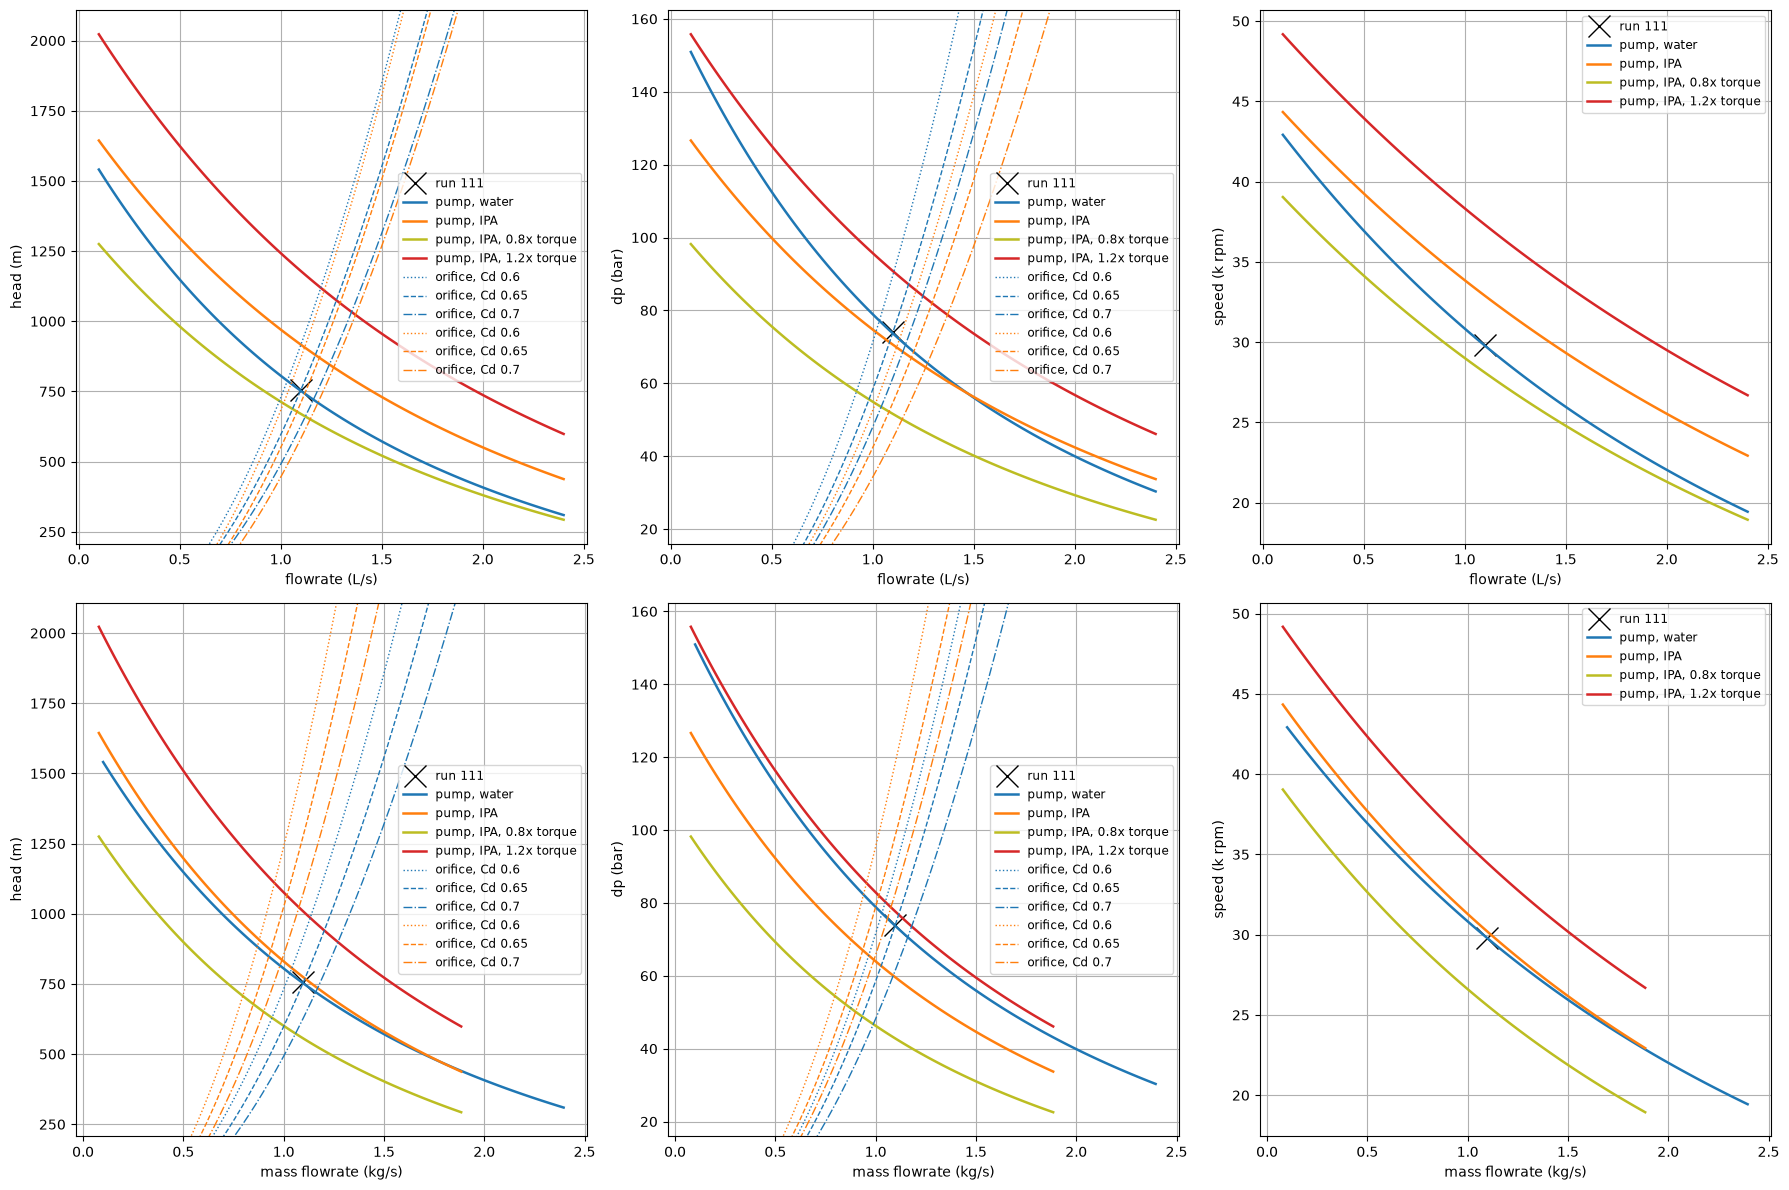

In [141]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

TESTBED = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TESTBED))

import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq
from pyfluids import FluidsList, Input
from otp.propellants.propellant import Propellant
from otp.pump.analysis import Pump
from otp.pump.records import PumpChoices, PumpGeometry, PumpRequirements
from otp.turbine.analysis import Turbine
from otp.turbine.records import TurbineChoices, TurbineGeometry, TurbineInletGas, TurbineRequirements
from otp.core.units import K_TO_C, g

T_K, P_IN, P_AMB = 293.15, 17.52 * BAR, 1.01325 * BAR  #K, bar, bar
N_MEAS = 29800
FLOWRATES = np.linspace(0.1e-3, 2.4e-3, 100)

GEOM = PumpGeometry(d_inlet=0.0298 / 1.2,
                    d_1=0.0298, 
                    d_2=0.0689,
                    b_1=0.0074,
                    b_2=0.0032,
                    d_throat=0.0062, 
                    d_outlet=0.0115,
                    d_3=0.0, 
                    b_3=0.0, 
                    s_ax=0.0)            # unused
PUMP = Pump(PumpRequirements(None, 1.2e-3, 760.0), PumpChoices(24e3, 6, 1.0), GEOM)

class IPA:                      # CoolProp has no propan-2-ol; 20 C literature values
    class _s: density, kinematic_viscosity, pressure = 785.4, 2.66e-6, 4400.0
    class fluid:
        with_state = staticmethod(lambda *a: IPA._s)   # .pressure only read for p_sat
WATER = Propellant("Water", FluidsList.Water, t_tank=T_K, p_tank=P_IN)
# IPA = Propellant("Water", FluidsList.Water, t_tank=T_K, p_tank=P_IN)


def head_at_flow_torque(fl, flowrate, torque):
    f = lambda rpm: PUMP.point_performance(fl, flowrate, rpm, P_IN, T_K, "lock").torque - torque
    try:
        solved_rpm = brentq(f, 10000, 50000)
        solved_perf = PUMP.point_performance(fl, flowrate, solved_rpm, P_IN, T_K, "lock")
        return solved_perf.H_total_real, solved_perf.dp, solved_rpm
    except:
        solved_rpm = np.nan
        return np.nan, np.nan, np.nan
    
def rho(fl):
    return fl.fluid.with_state(Input.pressure(1e5), Input.temperature(T_K + K_TO_C)).density

CD = 0.65
D_OR = 0.004

def pump_torque(n, fl):
    """Torque on the 4 mm orifice line: Q where pump dp drives that flow."""
    A = np.pi / 4 * D_OR ** 2
    f = lambda Q: CD * A * np.sqrt(2 * max(PUMP.point_performance(fl, Q, n, P_IN, T_K, "lock").p_outlet - P_AMB, 0) / rho(fl)) - Q
    solved_Q = brentq(f, 1e-7, Q_HI)
    return PUMP.point_performance(fl, solved_Q, n, P_IN, T_K, "lock").torque, solved_Q

test_torque, solved_Q = pump_torque(N_MEAS, WATER)
print(f"test torque: {test_torque:.2f} N.m, test flowrate: {solved_Q:.6f} m3/s")

CASES = {0: {"fluid": WATER, "color": "tab:blue", "label": "water", "torque_mult": 1.0},
            1: {"fluid": IPA, "color": "tab:orange", "label": "IPA", "torque_mult": 1.0},
            2: {"fluid": IPA, "color": "tab:olive", "label": "IPA, 0.8x torque", "torque_mult": 0.8},
            3: {"fluid": IPA, "color": "tab:red", "label": "IPA, 1.2x torque", "torque_mult": 1.2}}

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
[ax1, ax2, ax3, ax4, ax5, ax6] = axs.flatten()
ax1.plot(solved_Q * 1e3, 756, "kx", ms=16, label="run 111")
ax4.plot(solved_Q * 1e3, 756, "kx", ms=16, label="run 111")
ax2.plot(solved_Q * 1e3, 74, "kx", ms=16, label="run 111")
ax5.plot(solved_Q * 1e3, 74, "kx", ms=16, label="run 111")
ax3.plot(solved_Q * 1e3, N_MEAS / 1e3, "kx", ms=16, label="run 111")
ax6.plot(solved_Q * 1e3, N_MEAS / 1e3, "kx", ms=16, label="run 111")

for case in CASES.values():
    fl, c, label, torque_mult = case["fluid"], case["color"], case["label"], case["torque_mult"]

    perf_array = np.array([head_at_flow_torque(fl, flowrate, test_torque * torque_mult) for flowrate in FLOWRATES])
    head_array = perf_array[:, 0]
    dp_array = perf_array[:, 1]
    rpm_array = perf_array[:, 2]

    ax1.plot(FLOWRATES * 1e3, head_array, c, lw=1.8, label="pump, " + label)
    ax2.plot(FLOWRATES * 1e3, dp_array / BAR, c, lw=1.8, label="pump, " + label)
    ax3.plot(FLOWRATES * 1e3, rpm_array / 1e3, c, lw=1.8, label="pump, " + label)

    ax4.plot(FLOWRATES * rho(fl), head_array, c, lw=1.8, label="pump, " + label)
    ax5.plot(FLOWRATES * rho(fl), dp_array / BAR, c, lw=1.8, label="pump, " + label)
    ax6.plot(FLOWRATES * rho(fl), rpm_array / 1e3, c, lw=1.8, label="pump, " + label)

A_OR = np.pi / 4 * D_OR ** 2
Q_F = np.linspace(FLOWRATES[0], FLOWRATES[-1], 200)
for fl, c, lab in [(WATER, "tab:blue", True), (IPA, "tab:orange", False)]:
# for fl, c, lab in [(IPA, "tab:orange", False)]:
    r = rho(fl)
    for cd, ls in [(0.6, ":"), (0.65, "--"), (0.7, "-.")]:
        dp_or = 0.5 * r * (Q_F / (cd * A_OR)) ** 2 - (P_IN - P_AMB)      # pump dp this orifice needs at Q
        for ax, x, y in [(ax1, Q_F * 1e3, dp_or / (r * g)), (ax2, Q_F * 1e3, dp_or / BAR),
                         (ax4, Q_F * r, dp_or / (r * g)), (ax5, Q_F * r, dp_or / BAR)]:
            lim = ax.get_ylim()
            ax.plot(x, y, c, ls=ls, lw=1, label=f"orifice, Cd {cd}")
            ax.set_ylim(lim)

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.legend(fontsize="small", loc="best")
    ax.grid(True)

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("flowrate (L/s)")

for ax in [ax4, ax5, ax6]:
    ax.set_xlabel("mass flowrate (kg/s)")


ax1.set_ylabel("head (m)")
ax4.set_ylabel("head (m)")
ax2.set_ylabel("dp (bar)")
ax5.set_ylabel("dp (bar)")
ax3.set_ylabel("speed (k rpm)");
ax6.set_ylabel("speed (k rpm)");

fig.tight_layout(); plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
test torque: 5.33 N.m, test flowrate: 0.001200 m3/s


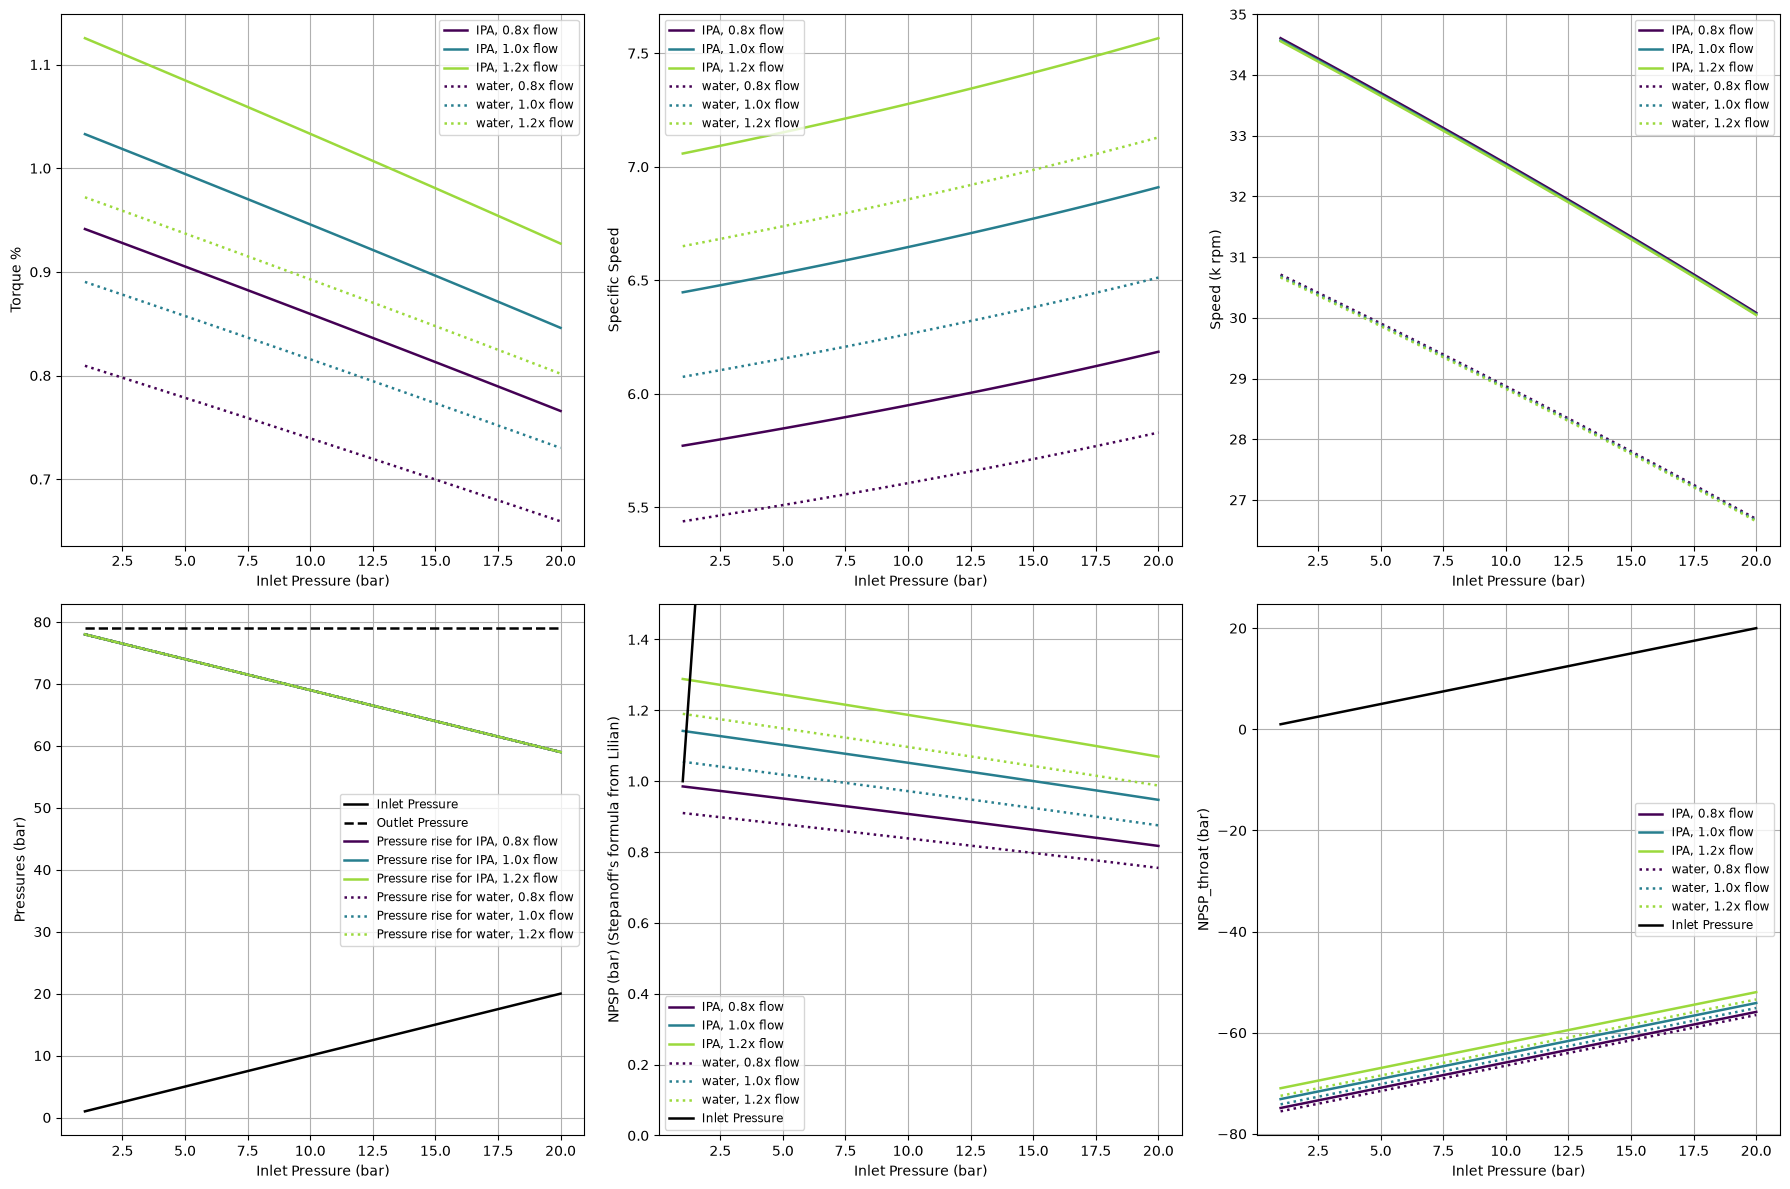

In [156]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

TESTBED = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TESTBED))

import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq
from pyfluids import FluidsList, Input
from otp.propellants.propellant import Propellant
from otp.pump.analysis import Pump
from otp.pump.records import PumpChoices, PumpGeometry, PumpRequirements
from otp.turbine.analysis import Turbine
from otp.turbine.records import TurbineChoices, TurbineGeometry, TurbineInletGas, TurbineRequirements
from otp.core.units import K_TO_C, g

T_K, P_IN, P_AMB = 293.15, 17.52 * BAR, 1.01325 * BAR  #K, bar, bar
N_MEAS = 29800
FLOWRATES = np.linspace(0.1e-3, 2.4e-3, 100)

GEOM = PumpGeometry(d_inlet=0.0298 / 1.2,
                    d_1=0.0298, 
                    d_2=0.0689,
                    b_1=0.0074,
                    b_2=0.0032,
                    d_throat=0.0062, 
                    d_outlet=0.0115,
                    d_3=0.0, 
                    b_3=0.0, 
                    s_ax=0.0)            # unused
PUMP = Pump(PumpRequirements(None, 1.2e-3, 760.0), PumpChoices(24e3, 6, 1.0), GEOM)

class IPA:                      # CoolProp has no propan-2-ol; 20 C literature values
    class _s: density, kinematic_viscosity, pressure = 785.4, 2.66e-6, 4400.0
    class fluid:
        with_state = staticmethod(lambda *a: IPA._s)   # .pressure only read for p_sat


CD = 0.71
D_OR = 0.004

def pump_torque(n, fl):
    """Torque on the 4 mm orifice line: Q where pump dp drives that flow."""
    A = np.pi / 4 * D_OR ** 2
    f = lambda Q: CD * A * np.sqrt(2 * max(PUMP.point_performance(fl, Q, n, P_IN, T_K, "lock").p_outlet - P_AMB, 0) / rho(fl)) - Q
    solved_Q = brentq(f, 1e-7, Q_HI)
    return PUMP.point_performance(fl, solved_Q, n, P_IN, T_K, "lock").torque, solved_Q

test_torque, solved_Q = pump_torque(N_MEAS, WATER)
print(f"test torque: {test_torque:.2f} N.m, test flowrate: {solved_Q:.6f} m3/s")

# Sweep x-axis inlet pressure, y-axis pump torque %, specific speed, npshr, rpm
# for a given inlet pressure, find the required rpm to achieved 0.88kg/s, +/-10%

def perf_solver(mdot_desired, inlet_pressure, outlet_pressure, fl):
    Q = mdot_desired / rho(fl)
    f = lambda n: PUMP.point_performance(fl, Q, n, inlet_pressure, T_K, "lock").p_outlet - outlet_pressure
    try:
        solved_rpm = brentq(f, 10000, 50000)
        return PUMP.point_performance(fl, Q, solved_rpm, inlet_pressure, T_K, "lock")
    except:
        return None

CASES = {
            0: {"fluid": IPA, "label": "IPA, 0.8x flow", "flow_mult": 0.8, "color_index": 0, "linestyle": "-"},
            1: {"fluid": IPA, "label": "IPA, 1.0x flow", "flow_mult": 1.0, "color_index": 1, "linestyle": "-"},
            2: {"fluid": IPA, "label": "IPA, 1.2x flow", "flow_mult": 1.2, "color_index": 2, "linestyle": "-"},
            3: {"fluid": WATER, "label": "water, 0.8x flow", "flow_mult": 0.8, "color_index": 0, "linestyle": ":"},
            4: {"fluid": WATER, "label": "water, 1.0x flow", "flow_mult": 1.0, "color_index": 1, "linestyle": ":"},
            5: {"fluid": WATER, "label": "water, 1.2x flow", "flow_mult": 1.2, "color_index": 2, "linestyle": ":"},}
colors = plt.get_cmap(plt.cm.viridis)(np.linspace(0, 0.85, 3))

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
[ax1, ax2, ax3, ax4, ax5, ax6] = axs.flatten()

DESIRED_FLOWRATE = 0.88
DESIRED_PRESSURE = 79*BAR
INLET_PRESSURES = np.linspace(1.0 * BAR, 20.0 * BAR, 100)


ax4.plot(INLET_PRESSURES / BAR, INLET_PRESSURES / BAR, color="black", lw=1.8, label="Inlet Pressure")
ax4.plot(INLET_PRESSURES / BAR, DESIRED_PRESSURE / BAR * np.ones_like(INLET_PRESSURES), color="black", lw=1.8, ls="--", label="Outlet Pressure")

for case in CASES.values():
    fl, label, flow_mult, color_index, linestyle = case["fluid"], case["label"], case["flow_mult"], case["color_index"], case["linestyle"]
    mdot_desired = DESIRED_FLOWRATE * flow_mult
    perf_array = np.array([perf_solver(mdot_desired, inlet_pressure, DESIRED_PRESSURE, fl) for inlet_pressure in INLET_PRESSURES])
    npsp_r = np.array([0.00122 * perf.specific_speed**(4/3) * perf.dp/BAR for perf in perf_array])

    ax1.plot(INLET_PRESSURES / BAR, [perf.torque/test_torque for perf in perf_array], color=colors[color_index], lw=1.8, label=label, ls=linestyle)
    ax2.plot(INLET_PRESSURES / BAR, [perf.specific_speed for perf in perf_array], color=colors[color_index], lw=1.8, label=label, ls=linestyle)
    ax3.plot(INLET_PRESSURES / BAR, [perf.rpm/1e3 for perf in perf_array], color=colors[color_index], lw=1.8, label=label, ls=linestyle)
    ax4.plot(INLET_PRESSURES / BAR, [perf.dp/BAR for perf in perf_array], color=colors[color_index], lw=1.8, ls=linestyle, label=f"Pressure rise for {label}")
    ax5.plot(INLET_PRESSURES / BAR, npsp_r, color=colors[color_index], lw=1.8, label=label, ls=linestyle)
    ax6.plot(INLET_PRESSURES / BAR, [perf.npsh_r_throat * g * rho(fl) / BAR for perf in perf_array], color=colors[color_index], lw=1.8, label=label, ls=linestyle)

ax5.plot(INLET_PRESSURES / BAR, INLET_PRESSURES / BAR, color="black", lw=1.8, label="Inlet Pressure")
ax6.plot(INLET_PRESSURES / BAR, INLET_PRESSURES / BAR, color="black", lw=1.8, label="Inlet Pressure")
ax5.set_ylim(0, 1.5)

for ax in axs.flatten():
    ax.grid(True)
    ax.legend(fontsize="small", loc="best")
    ax.set_xlabel("Inlet Pressure (bar)")

ax1.set_ylabel("Torque %")
ax2.set_ylabel("Specific Speed")
ax3.set_ylabel("Speed (k rpm)")
ax4.set_ylabel("Pressures (bar)")
ax5.set_ylabel("NPSP (bar) (Stepanoff's formula from Lilian)")
ax6.set_ylabel("NPSP_throat (bar)")

fig.tight_layout(); plt.show()
